D3 Huawei — iterative vs one-shot pruning


Saving traffic-prediction-dataset.csv to traffic-prediction-dataset.csv

===== SEED 1 =====
  baseline (seed 1)
    epoch  1/20  loss 0.009429
    epoch  2/20  loss 0.001998
    epoch  3/20  loss 0.001783
    epoch  4/20  loss 0.001702
    epoch  5/20  loss 0.001703
    epoch  6/20  loss 0.001636
    epoch  7/20  loss 0.001646
    epoch  8/20  loss 0.001624
    epoch  9/20  loss 0.001599
    epoch 10/20  loss 0.001633
    epoch 11/20  loss 0.001603
    epoch 12/20  loss 0.001620
    epoch 13/20  loss 0.001599
    epoch 14/20  loss 0.001569
    epoch 15/20  loss 0.001567
    epoch 16/20  loss 0.001591
    epoch 17/20  loss 0.001550
    epoch 18/20  loss 0.001573
    epoch 19/20  loss 0.001562
    epoch 20/20  loss 0.001565
  one-shot fine-tune 80% (seed 1)
    epoch  1/20  loss 0.005530
    epoch  2/20  loss 0.001733
    epoch  3/20  loss 0.001637
    epoch  4/20  loss 0.001609
    epoch  5/20  loss 0.001586
    epoch  6/20  loss 0.001567
    epoch  7/20  loss 0.001561
    epoch  8/20  

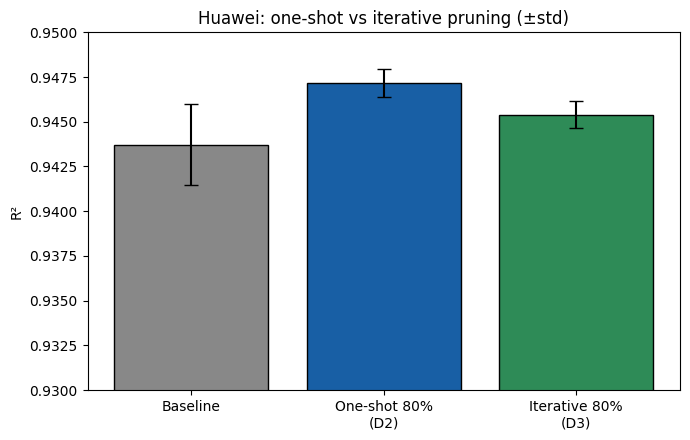

In [1]:
# ============================================================================
# D3 — IMPROVEMENT: ITERATIVE PRUNING vs ONE-SHOT PRUNING (D2) — HUAWEI
# Builds on the D2 pipeline (UNCHANGED architecture/preprocessing).
# D2 = one-shot pruning (cut to 80% at once). D3 = iterative pruning
# (20->40->60->80% with fine-tuning between steps). Seeds [1, 7, 13], error bars.
# ============================================================================

# ===== HUAWEI =====
# ############################################################################

# ---------------- A1: imports ----------------
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import copy, io, torch, torch.nn as nn
import torch.nn.utils.prune as prune
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEEDS = [1, 7, 13]; EPOCHS = 20
print("D3 Huawei — iterative vs one-shot pruning")

# ---------------- A2: upload + preprocessing (same as D1/D2) ----------------
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0]); df.columns = [c.strip() for c in df.columns]
LANES = ["Cross 1","Cross 2","Cross 3","Cross 4"]
data = df[LANES].astype(float).copy()
def fix_zeros_moving_avg(series, window=12):
    vals = series.values.astype(float)
    for i in range(len(vals)):
        if vals[i]==0:
            prev = vals[max(0,i-window):i]; prev = prev[prev>0]
            if len(prev)>0: vals[i]=prev.mean()
    return pd.Series(vals, index=series.index)
for c in LANES: data[c]=fix_zeros_moving_avg(data[c])
split_idx=int(len(data)*0.75)
scaler=MinMaxScaler(); train_scaled=scaler.fit_transform(data.iloc[:split_idx]); test_scaled=scaler.transform(data.iloc[split_idx:])
def make_windows(arr, window=12):
    X,Y=[],[]
    for i in range(len(arr)-window): X.append(arr[i:i+window].flatten()); Y.append(arr[i+window])
    return np.array(X,np.float32), np.array(Y,np.float32)
X_train,Y_train=make_windows(train_scaled); X_test,Y_test=make_windows(test_scaled)
vc=int(len(X_train)*0.9); X_tr,Y_tr=X_train[:vc],Y_train[:vc]
to_t=lambda a: torch.tensor(a,dtype=torch.float32); X_tr_t,Y_tr_t,X_te_t=to_t(X_tr),to_t(Y_tr),to_t(X_test)

def evaluate(pred):
    yt=scaler.inverse_transform(Y_test).flatten(); yp=scaler.inverse_transform(pred).flatten(); mask=yt>1e-6
    return {"R2":r2_score(yt,yp),"MAE":mean_absolute_error(yt,yp),
            "RMSE":np.sqrt(mean_squared_error(yt,yp)),
            "MAPE":np.mean(np.abs((yt[mask]-yp[mask])/yt[mask]))*100}
def agg(runs):
    ks=runs[0].keys(); return {k:(float(np.mean([r[k] for r in runs])),float(np.std([r[k] for r in runs]))) for k in ks}
def fmt(s): return f"{s[0]:.4f} +/- {s[1]:.4f}"

class TrafficMLP(nn.Module):
    def __init__(self,in_dim=48,out_dim=4):
        super().__init__(); self.net=nn.Sequential(nn.Linear(in_dim,128),nn.ReLU(),nn.Linear(128,64),nn.ReLU(),nn.Linear(64,out_dim))
    def forward(self,x): return self.net(x)
def train_mlp(model,Xtr,Ytr,seed,epochs=EPOCHS,bs=64,lr=0.001,label=""):
    torch.manual_seed(seed); opt=torch.optim.Adam(model.parameters(),lr=lr); crit=nn.MSELoss(); n=len(Xtr)
    if label: print(f"  {label} (seed {seed})")
    for ep in range(epochs):
        model.train(); perm=torch.randperm(n); run=0.0
        for i in range(0,n,bs):
            idx=perm[i:i+bs]; opt.zero_grad(); loss=crit(model(Xtr[idx]),Ytr[idx]); loss.backward(); opt.step(); run+=loss.item()*len(idx)
        print(f"    epoch {ep+1:2d}/{epochs}  loss {run/n:.6f}")
    return model
def predict(m):
    m.eval()
    with torch.no_grad(): return m(X_te_t).numpy()
def lin_mods(m): return [x for x in m.modules() if isinstance(x,nn.Linear)]

# ---------------- A3: one-shot (D2) and iterative (D3) pruning ----------------
def oneshot_prune(base, seed, target=0.8):
    m=copy.deepcopy(base); mods=lin_mods(m)
    prune.global_unstructured([(x,'weight') for x in mods],pruning_method=prune.L1Unstructured,amount=target)
    m=train_mlp(m,X_tr_t,Y_tr_t,seed,label=f"one-shot fine-tune {int(target*100)}%")
    for x in mods: prune.remove(x,'weight')
    return m
def iterative_prune(base, seed, steps=[0.2,0.4,0.6,0.8]):
    m=copy.deepcopy(base); mods=lin_mods(m); prev=0
    for tgt in steps:
        amt = tgt if prev==0 else (tgt-prev)/(1-prev)   # extra fraction of what REMAINS
        prune.global_unstructured([(x,'weight') for x in mods],pruning_method=prune.L1Unstructured,amount=amt)
        m=train_mlp(m,X_tr_t,Y_tr_t,seed,label=f"iterative step ->{int(tgt*100)}%"); prev=tgt
    for x in mods: prune.remove(x,'weight')
    return m

# ---------------- A4: run across seeds ----------------
base_runs, os_runs, it_runs = [], [], []
for s in SEEDS:
    print(f"\n===== SEED {s} =====")
    torch.manual_seed(s); base=train_mlp(TrafficMLP(),X_tr_t,Y_tr_t,s,label="baseline")
    base_runs.append(evaluate(predict(base)))
    os_runs.append(evaluate(predict(oneshot_prune(base,s))))
    it_runs.append(evaluate(predict(iterative_prune(base,s))))
base_s,os_s,it_s = agg(base_runs),agg(os_runs),agg(it_runs)

print("\n=== HUAWEI: D3 comparison (mean +/- std over seeds", SEEDS, ") ===")
print(f"  Baseline MLP        R2 = {fmt(base_s['R2'])}")
print(f"  One-shot 80% (D2)   R2 = {fmt(os_s['R2'])}")
print(f"  Iterative 80% (D3)  R2 = {fmt(it_s['R2'])}")
winner = "Iterative (D3)" if it_s['R2'][0] >= os_s['R2'][0] else "One-shot (D2)"
print(f"  -> better pruning method: {winner}")

# ---------------- A5: comparison bar plot ----------------
labels=["Baseline","One-shot 80%\n(D2)","Iterative 80%\n(D3)"]
means=[base_s['R2'][0],os_s['R2'][0],it_s['R2'][0]]; stds=[base_s['R2'][1],os_s['R2'][1],it_s['R2'][1]]
plt.figure(figsize=(7,4.5))
plt.bar(range(3),means,yerr=stds,capsize=5,color=["#888","#185FA5","#2e8b57"],edgecolor="black")
plt.xticks(range(3),labels); plt.ylim(0.93,0.95); plt.ylabel("R²")
plt.title("Huawei: one-shot vs iterative pruning (±std)")
plt.tight_layout(); plt.show()